# Clusterización

Es una técnica de aprendizaje no supervisado que agrupa datos en conjuntos o clusteres según sus similitudes. 
Esto permite descubrir tendencias, segmentar datos y optimizar procesos en diversos campos como el marketing, la biomedicina, finanzas, educación, IA, etc.
- La segmentación de datos es útil porque permite dividir grandes volúmenes de datos en grupos más manejables.
- Reduce la dimensionalidad facilitando el análisis egrandes conjuntos de datos.


## Algoritmos de clusterización

- Particionales (K-Means, K-Medoids): Dividen los datos en un número fijo de clusteres.
- Basados en densidad (DBSCAN): Encuentran clusteres con base en la densidad de puntos.

Elegir el algoritmo adecuado depende de la naturaleza de los datos y los objetivos del análisis.

## K-Means clustering 

Pasos para implementar el algoritmo K-Means:

1. Se elige el número de centroides (K) que se desea formar, se puede usar el método del codo para determinar el número óptimo de clusters, elegir un número aleatorio o un número basado en el conocimiento del problema o análisis que se va a hacer.
2. Seleccionar aleatoriamente los centroides.
3. Asignar los clusteres a cada punto de datos según la distancia más cercana al centroide.
4. Recalcular los centroides como la media de los puntos asignados a cada cluster.
5. Repetir los pasos 3 y 4 hasta que los centroides no cambien significativamente o se alcance el número máximo de iteraciones.

In [ ]:
#Librería para aplicar el algoritmo de K-Means
%pip install scikit-learn


   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------------------------ --------------- 5.0/8.1 MB 34.5 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 34.6 MB/s  0:00:00
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   ----- ---------------------------------- 5.0/37.3 MB 23.5 MB/s eta 0:00:02
   ----------------- ---------------------- 16.3/37.3 MB 39.8 MB/s eta 0:00:01
   ------------------------------ --------- 28.0/37.3 MB 45.7 MB/s eta 0:00:01
   ---------------------------------------- 37.3/37.3 MB 45.7 MB/s  0:00:00

   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   --


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
#Librerías necesarias para el análisis de datos, visualización y escalado por ahora
from sklearn.cluster import KMeans
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

#Cargamos un dataset pa pruebas
iris = sb.load_dataset('iris')
print(iris['species'].unique())
iris.head()

<StringArray>
['setosa', 'versicolor', 'virginica']
Length: 3, dtype: str


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [2]:
#Eliminamos columnas que no se utilizarán para el clustering
iris_clustering = iris.drop(columns=['species'])
iris_clustering.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [3]:
#Escalamos los datos para que el algoritmo de K-Means funcione mejor
scaler = StandardScaler()
iris_scaled = scaler.fit_transform(iris_clustering) #Esto devuelve un array de numpy, no un DataFrame
iris_scaled[:5] #Mostramos las primeras filas del dataset escalado

array([[-0.90068117,  1.01900435, -1.34022653, -1.3154443 ],
       [-1.14301691, -0.13197948, -1.34022653, -1.3154443 ],
       [-1.38535265,  0.32841405, -1.39706395, -1.3154443 ],
       [-1.50652052,  0.09821729, -1.2833891 , -1.3154443 ],
       [-1.02184904,  1.24920112, -1.34022653, -1.3154443 ]])

In [4]:
#Comprobar valores 
df_iris_scaled = pd.DataFrame(iris_scaled, columns=iris_clustering.columns)
print(iris_clustering)
df_iris_scaled.head()

     sepal_length  sepal_width  petal_length  petal_width
0             5.1          3.5           1.4          0.2
1             4.9          3.0           1.4          0.2
2             4.7          3.2           1.3          0.2
3             4.6          3.1           1.5          0.2
4             5.0          3.6           1.4          0.2
..            ...          ...           ...          ...
145           6.7          3.0           5.2          2.3
146           6.3          2.5           5.0          1.9
147           6.5          3.0           5.2          2.0
148           6.2          3.4           5.4          2.3
149           5.9          3.0           5.1          1.8

[150 rows x 4 columns]


,sepal_length,sepal_width,petal_length,petal_width
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


Fórmula WCSS que es la suma de los cuadrados dentro del cluster 
$$WCSS = \sum_{i=1}^{k} \sum_{x_j \in C_i} ||x_j - \mu_i||^2$$

Donde:
- ($k$) = Número de clústeres
- ($C_i$) = Conjunto de puntos en el clúster ($i$)
- ($x_j$) = Punto de datos en el clúster ($C_i$)
- ($\mu_i$) = Centroide del clúster ($i$)
- ($||x_j - \mu_i||^2$) = Distancia euclidiana al cuadrado entre cada punto y su centroide

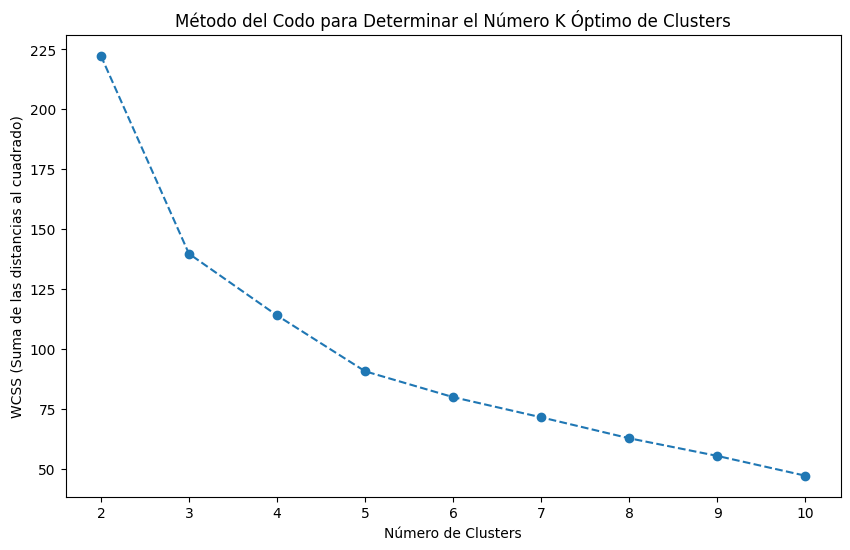

In [6]:
#Aplicación del método del codo para determinar el número óptimo de clusters
wcss = [] #Lista para almacenar la suma de las distancias al cuadrado dentro de cada cluster
for i in range(2, 11): #Probamos con un rango de 2 a 10 clusters
    kmeans = KMeans(n_clusters=i, max_iter=300,random_state=0, init='k-means++', n_init=10) #Creamos el modelo de K-Means
    kmeans.fit(iris_scaled) #Ajustamos el modelo a los datos escalados
    wcss.append(kmeans.inertia_) #Agregamos la suma de las distancias al cuadrado a la lista
    
#Graficamos el método del codo
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), wcss, marker='o', linestyle='--') #Graficamos el número de clusters vs la suma de las distancias al cuadrado
plt.xlabel('Número de Clusters') #Etiqueta del eje x
plt.ylabel('WCSS (Suma de las distancias al cuadrado)') #Etiqueta del eje y
plt.title('Método del Codo para Determinar el Número K Óptimo de Clusters') #Título del gráfico
plt.show() #Mostramos el gráfico

Hay que fijarse en los puntos y su descenso en la gráfica, Imaginemos que el gráfico es un brazo que está doblado, el punto que más se parezca al codo del brazo va a ser el valor de k que usaremos en nuestro algortimo k-means, en este caso vendría siendo el 3 porque es donde se ve la caída más drástica en el gráfico (Una valor de k en este caso mayor a 3 es más propenso a overfitting(se complicaría el modelo innecesariamente)). Entonces el "codo" es el punto donde sucede la caída más drástica y notable del WCSS se detiene y la curva empieza a aplanarse.

In [7]:
#Aplicamos el algoritmo k-means con k = 3 
kmeans = KMeans(n_clusters=3, max_iter=300, random_state=0, init='k-means++', n_init=10) #Creamos el modelo de K-Means con 3 clusters
kmeans.fit(iris_scaled) #Ajustamos el modelo a los datos escalados
#Obtener etiqueta del cluster
cluster_label= kmeans.labels_ #Obtenemos las etiquetas de los clusters asignados a cada muestra
print(cluster_label) #Mostramos las etiquetas de los clusters
centroids = kmeans.cluster_centers_ #Obtenemos los centroides de los clusters
print(centroids) #Mostramos los centroides de los clusters

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 0 0 0 2 0 0 0 0 0 0 0 0 2 0 0 0 0 2 0 0 0
 0 2 2 2 0 0 0 0 0 0 0 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 2 2 2 2 2 2 0 0 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]
[[-0.05021989 -0.88337647  0.34773781  0.2815273 ]
 [-1.01457897  0.85326268 -1.30498732 -1.25489349]
 [ 1.13597027  0.08842168  0.99615451  1.01752612]]


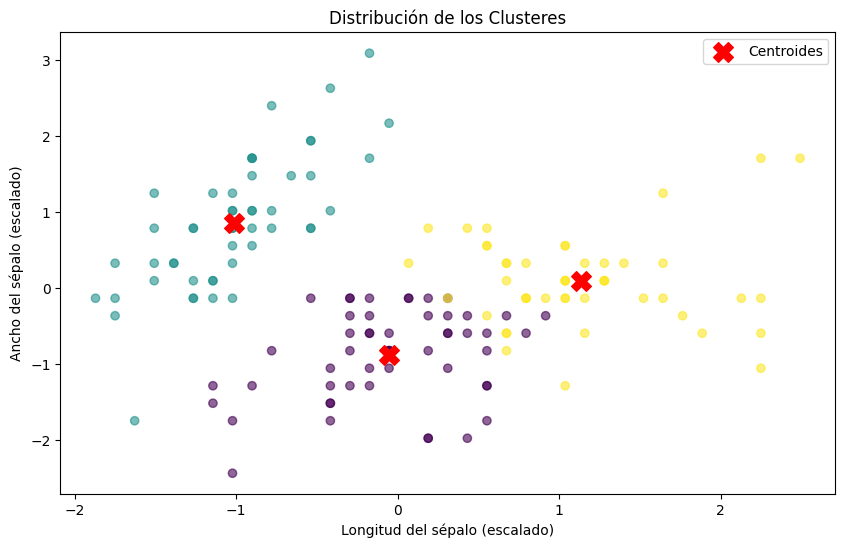

In [8]:
#Graficar clusteres según dos características
plt.figure(figsize=(10, 6))
plt.scatter(iris_scaled[:, 0], iris_scaled[:, 1], c=cluster_label, cmap='viridis', alpha=0.6) #Graficamos las muestras con colores según su cluster asignado
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:, 1],c='red', marker='X', s=200, label='Centroides') #Graficamos los centroides
plt.xlabel('Longitud del sépalo (escalado)') #Etiqueta del eje x
plt.ylabel('Ancho del sépalo (escalado)') #Etiqueta del eje y
plt.title('Distribución de los Clusteres') #Título del gráfico
plt.legend() #Mostramos la leyenda
plt.show() #Mostramos el gráfico

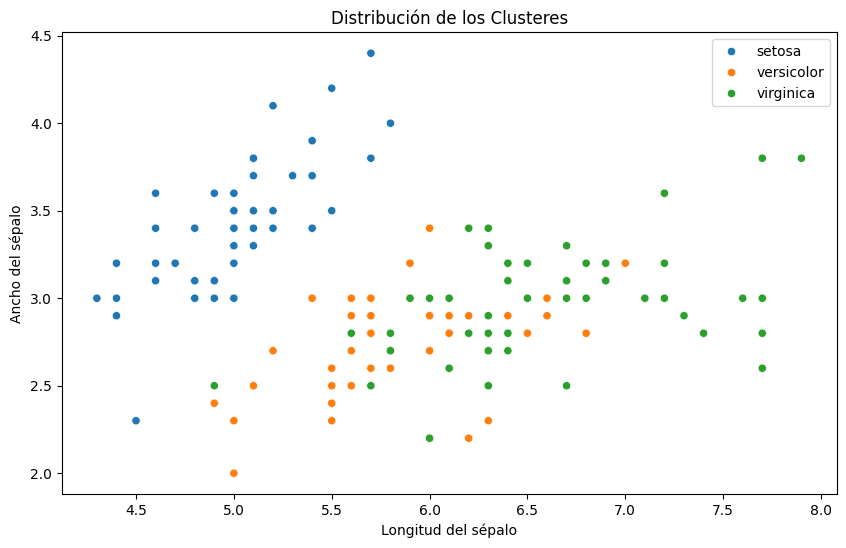

In [9]:
#Graficamos con 'especies' para comparar con los clusters obtenidos
plt.figure(figsize=(10, 6))
sb.scatterplot(data=iris, x="sepal_length", y="sepal_width", hue="species") #Graficamos las muestras con colores según su especie
plt.xlabel('Longitud del sépalo') #Etiqueta del eje x
plt.ylabel('Ancho del sépalo') #Etiqueta del eje y  
plt.title('Distribución de los Clusteres') #Título del gráfico
plt.legend() #Mostramos la leyenda
plt.show() #Mostramos el gráfico

¿Por qué K-Means no supo segmentar correctamente en comparación con la data real del dataset?
Hay tres razones técnicas fundamentales por las que K-Means falló en este caso específico:
- La suposición de esfericidad (El "pecado" de K-Means)K-Means utiliza la distancia euclidiana. Matemáticamente, esto asume que todos los clústeres son esféricos (o circulares en 2D) y de un tamaño similar.El problema: Tus datos reales tienen formas alargadas. K-Means no puede "entender" una forma de salchicha; siempre intentará dibujar círculos alrededor de los centroides.
- Sensibilidad a la escala y varianzaSi una variable se extiende más que otra (como se ve en el eje X comparado con el Y), K-Means le dará más importancia a la variable con mayor rango. Aunque parece que tus ejes están equilibrados, la covarianza (la dirección en la que se estiran los datos) confunde al algoritmo porque este no la toma en cuenta.
- El criterio de "Centroide"K-Means solo busca minimizar la distancia al centro ($\mu_i$). No le importa si hay un "hueco" de densidad o si la forma tiene una curva. Si un punto del grupo alargado está físicamente más cerca del centro del grupo de al lado, lo robará.

El algoritmo K-Means no ve grupos sino que busca centros. Al trabajar exclusivamente con distancias euclidianas, el algoritmo asume que los clústeres deben ser circulares. Cuando los datos reales tienen formas alargadas o irregulares, el algoritmo termina cortando los grupos de forma arbitraria para que encajen en su lógica de esferas.
En conclusión.

El gráfico del codo ayudó a encontrar que k=3 era el número óptimo para reducir el error interno (WCSS), pero eso no significa que el algoritmo haya entendido la estructura de los datos. Esto demuestra que puedes tener una métrica matemática "perfecta" y aun así tener un modelo que no representa la realidad.

In [12]:
from sklearn.metrics import silhouette_score
silhouette_score(iris_scaled, cluster_label) #Calculamos el coeficiente de silueta para evaluar la calidad del clustering
#El coeficiente de silueta varía entre -1 y 1, donde valores cercanos a 1 indican que las muestras están bien agrupadas, valores cercanos a 0 indican que las muestras están en el límite entre dos clusters, y valores negativos indican que las muestras podrían estar asignadas al cluster incorrecto. Y valores cercanos a 0.5 o superiores generalmente indican una buena separación entre los clusters.

0.45994823920518646